In [ ]:
%%capture
%pip install accelerate peft bitsandbytes transformers trl

In [ ]:
#!huggingface-cli login
from huggingface_hub import login
login("token")

In [ ]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig
from trl import SFTTrainer

In [ ]:
# Model from Hugging Face hub
base_model = "Joseph7D/llama-2-7b-emotion-detector-v4"

# New instruction dataset
emotion_dataset = "Joseph7D/prompt-emotion-dataset-v2"


In [ ]:
dataset = load_dataset(emotion_dataset, split='test')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/671 [00:00<?, ?B/s]

(…)-00000-of-00001-0c67affb9210ad40.parquet:   0%|          | 0.00/2.38M [00:00<?, ?B/s]

(…)-00000-of-00001-4f62525995947485.parquet:   0%|          | 0.00/300k [00:00<?, ?B/s]

(…)-00000-of-00001-99d9ca9cf25d3c0d.parquet:   0%|          | 0.00/300k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26934 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3366 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3372 [00:00<?, ? examples/s]

In [ ]:
compute_dtype = getattr(torch, "float16")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=False,
)
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=quant_config,
    device_map={"": 0}
)
model.config.use_cache = False
model.config.pretraining_tp = 1

config.json:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/quantizers/auto.py:212: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors.index.json:   0%|          | 0.00/61.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.02G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

In [ ]:
# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

In [ ]:
!kill 26235

/bin/bash: line 1: kill: (26235) - No such process


In [ ]:
logging.set_verbosity(logging.CRITICAL)

# Suprime mensajes de advertencia
logging.set_verbosity(logging.CRITICAL)

# Define el prompt con el formato adecuado
prompt = """Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
"""

# Genera el resultado usando el pipeline
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Muestra el resultado
print(result[0]['generated_text'])

<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
 [/INST] ira 


In [ ]:
# Define el prompt con el formato adecuado
prompt = """Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Es INDIGNANTE las imágenes donde los tanques pasan por encima de las personas. Como pueden ser tan hijos de mil puta. 😥"
"""

# Genera el resultado usando el pipeline
# pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Muestra el resultado
print(result[0]['generated_text'])

<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Es INDIGNANTE las imágenes donde los tanques pasan por encima de las personas. Como pueden ser tan hijos de mil puta. 😥"
 [/INST] ira 


# Validation

In [ ]:
#!pip install tqdm

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import re
from tqdm import tqdm


# Separar prompt (input) y etiqueta (label) del formato instruct
def parse_sample(sample):
    text = sample["text"]  # campo 'text' del dataset
    inst_match = re.search(r"\[INST\](.*?)\[/INST\]", text, re.DOTALL)
    label_match = re.search(r"\[/INST\](.*?)</s>", text, re.DOTALL)

    if inst_match and label_match:
        input_text = inst_match.group(1).strip()
        label = label_match.group(1).strip().lower()
        return {"input": input_text, "label": label}
    else:
        return None

parsed_data = [parse_sample(s) for s in dataset if parse_sample(s)]


In [ ]:
model.eval()

# Generar predicciones
true_labels = []
pred_labels = []

for sample in tqdm(parsed_data, desc="Testing samples"):
    prompt = f"<s>[INST] {sample['input']} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt", return_attention_mask=True).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=10,
            do_sample=False
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extraer emoción generada
    generated_emotion = decoded.split("[/INST]")[-1].strip().lower()

    # Guardar resultados
    pred_labels.append(generated_emotion)
    true_labels.append(sample["label"])

# 5. Evaluar
print("=== CLASIFICATION REPORT ===")
print(classification_report(true_labels, pred_labels, digits=4))
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(true_labels, pred_labels))


Testing samples: 100%|██████████| 3366/3366 [32:29<00:00,  1.73it/s]

=== CLASIFICATION REPORT ===
              precision    recall  f1-score   support

     alegría     0.8675    0.8752    0.8713       561
    disgusto     0.9331    0.9447    0.9389       561
         ira     0.8376    0.8182    0.8278       561
       miedo     0.9295    0.9394    0.9344       561
     neutral     0.8964    0.8021    0.8467       561
    tristeza     0.7967    0.8734    0.8333       561

    accuracy                         0.8755      3366
   macro avg     0.8768    0.8755    0.8754      3366
weighted avg     0.8768    0.8755    0.8754      3366

=== CONFUSION MATRIX ===
[[491   2  12   5  29  22]
 [  0 530  20   1   9   1]
 [ 15  24 459   5  10  48]
 [  8   2   7 527   0  17]
 [ 28   8  35   3 450  37]
 [ 24   2  15  26   4 490]]


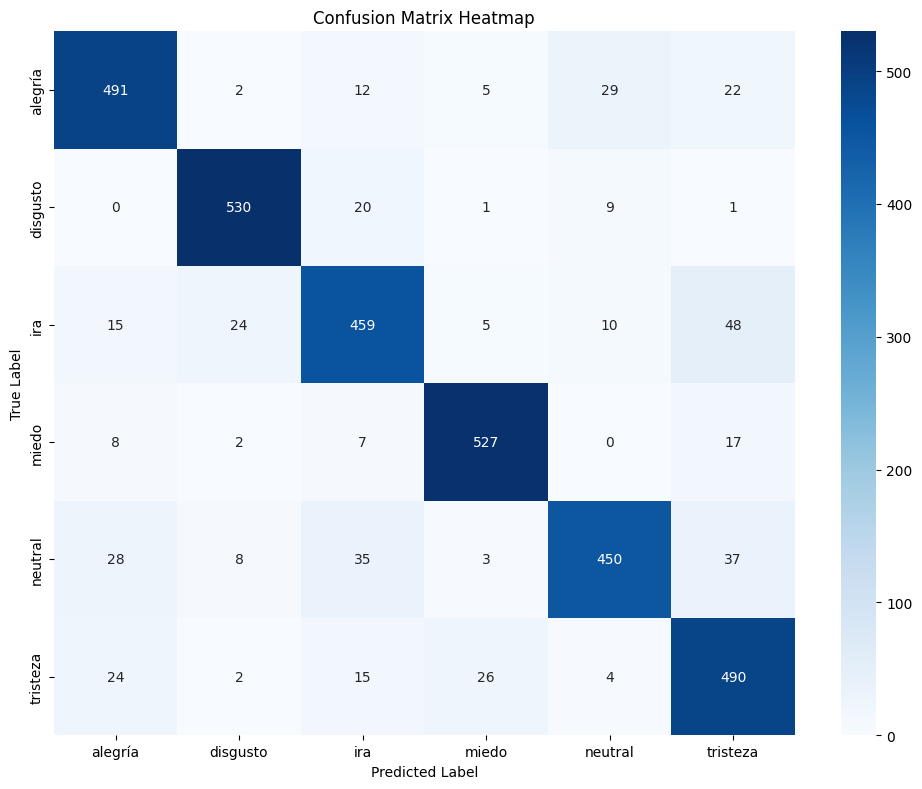

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Obtener etiquetas únicas (ordenadas por aparición en etiquetas reales)
labels = sorted(list(set(true_labels + pred_labels)))

# Matriz de confusión como array
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Crear mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Etiquetas y título
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()
